# Stage 02 — HELOC Feature Analysis and Modelling Decisions

This notebook evaluates the frozen Stage 01 data and proposes decisions for Stage 03. It does not alter the raw snapshot, split data, fit preprocessing, train a model, or run XAI.

## 1. Load and verify the frozen snapshot

The raw file is accepted only when its SHA-256 hash and expected structure match Stage 01 provenance.

In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pointbiserialr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "heloc": PROJECT_ROOT = PROJECT_ROOT.parents[2]
elif PROJECT_ROOT.name == "ml": PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "backend": PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "backend" / "data" / "heloc" / "raw" / "heloc_raw.csv"
ARTIFACT_DIR = PROJECT_ROOT / "backend" / "artifacts" / "heloc"
PLOT_DIR = ARTIFACT_DIR / "plots"
PROVENANCE_PATH = ARTIFACT_DIR / "dataset_provenance.json"
EXPECTED_HASH = "786b7e1885cf508ef66a968aae65a72bfde198d06d7666ac582958705b092570"
TARGET = "is_at_risk"
SPECIAL_CODES = [-9, -8, -7]

actual_hash = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
assert actual_hash == EXPECTED_HASH
with open(PROVENANCE_PATH, encoding="utf-8") as handle:
    provenance = json.load(handle)
assert provenance["raw_snapshot_sha256"] == EXPECTED_HASH

raw_df = pd.read_csv(RAW_PATH)
predictors = [column for column in raw_df.columns if column != TARGET]
X, y = raw_df[predictors], raw_df[TARGET]
assert raw_df.shape == (10_459, 24) and len(predictors) == 23
assert set(y.unique()) == {0, 1}

print("Raw SHA-256 verified:", actual_hash)
print("Shape:", raw_df.shape)
print("Target mapping: 0 = not at risk; 1 = at risk")
print("Mapping basis: persisted target name 'is_at_risk' and the persisted mstz/heloc risk-task provenance")

Raw SHA-256 verified: 786b7e1885cf508ef66a968aae65a72bfde198d06d7666ac582958705b092570
Shape: (10459, 24)
Target mapping: 0 = not at risk; 1 = at risk
Mapping basis: persisted target name 'is_at_risk' and the persisted mstz/heloc risk-task provenance


## 2. Feature and special-code semantics

The frozen source identifies the fields as credit-report predictors but provides names rather than detailed definitions. It does not define `-7`, `-8`, or `-9`; their meanings therefore remain unverified and the raw values are preserved.

In [2]:
semantics_evidence = pd.DataFrame([
    {"evidence": "Stage 01 DatasetInfo", "provenance": provenance["source_identifier"],
     "status": "VERIFIED", "finding": "23 integer predictors, binary is_at_risk target, risk configuration"},
    {"evidence": "Hugging Face dataset card linked in Stage 01", "provenance": "mstz/heloc README at frozen source revision",
     "status": "VERIFIED", "finding": "HELOC default-risk task and predictor names; no detailed definitions for negative codes"},
    {"evidence": "Observed raw values", "provenance": str(RAW_PATH.relative_to(PROJECT_ROOT)),
     "status": "VERIFIED", "finding": "Negative codes -7, -8 and -9 occur in predictors"},
    {"evidence": "Meaning of -7/-8/-9", "provenance": "Not exposed by frozen source metadata or dataset card",
     "status": "UNCONFIRMED", "finding": "No semantic labels assigned"},
])
display(semantics_evidence)

,evidence,provenance,status,finding
0,Stage 01 DatasetInfo,mstz/heloc,VERIFIED,"23 integer predictors, binary is_at_risk targe..."
1,Hugging Face dataset card linked in Stage 01,mstz/heloc README at frozen source revision,VERIFIED,HELOC default-risk task and predictor names; n...
2,Observed raw values,backend\data\heloc\raw\heloc_raw.csv,VERIFIED,"Negative codes -7, -8 and -9 occur in predictors"
3,Meaning of -7/-8/-9,Not exposed by frozen source metadata or datas...,UNCONFIRMED,No semantic labels assigned


## 3. Special values by feature and target

Counts are descriptive. Differences between target groups do not establish causation or justify automatic deletion.

,feature,count_-7,percentage_-7,count_-8,percentage_-8,count_-9,percentage_-9,total_special_coded_observations,percentage_special_coded
8,months_since_last_illegal_trade,4664,44.593173,176,1.682761,588,5.621952,5428,51.897887
18,net_fraction_of_installment_burden,0,0.000000,3419,32.689550,588,5.621952,4007,38.311502
14,months_since_last_inquiry_not_recent,1855,17.735921,476,4.551104,588,5.621952,2919,27.908978
20,nr_installment_trades_with_balance,0,0.000000,861,8.232145,588,5.621952,1449,13.854097
21,nr_banks_with_high_ratio,0,0.000000,583,5.574147,588,5.621952,1171,11.196099
1,months_since_first_trade,0,0.000000,239,2.285113,588,5.621952,827,7.907066
17,net_fraction_of_revolving_burden,0,0.000000,186,1.778373,588,5.621952,774,7.400325
19,nr_revolving_trades_with_balance,0,0.000000,156,1.491538,588,5.621952,744,7.113491
22,percentage_trades_with_balance,0,0.000000,18,0.172101,588,5.621952,606,5.794053
0,estimate_of_risk,0,0.000000,0,0.000000,598,5.717564,598,5.717564


,feature,target_value,special_value,count,group_rows,percentage_within_target
2,estimate_of_risk,0,-9,267,5000,5.340000
5,estimate_of_risk,1,-9,331,5459,6.063382
7,months_since_first_trade,0,-8,110,5000,2.200000
8,months_since_first_trade,0,-9,265,5000,5.300000
10,months_since_first_trade,1,-8,129,5459,2.363070
...,...,...,...,...,...,...
131,nr_banks_with_high_ratio,1,-9,323,5459,5.916835
133,percentage_trades_with_balance,0,-8,4,5000,0.080000
134,percentage_trades_with_balance,0,-9,265,5000,5.300000
136,percentage_trades_with_balance,1,-8,14,5459,0.256457


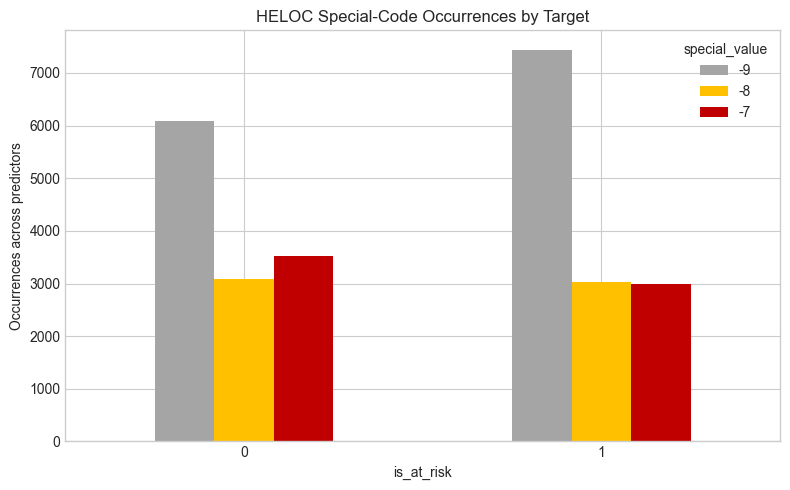

In [3]:
special_feature_rows = []
for feature in predictors:
    row = {"feature": feature}
    for value in [-7, -8, -9]:
        count = int(X[feature].eq(value).sum())
        row[f"count_{value}"] = count
        row[f"percentage_{value}"] = 100 * count / len(raw_df)
    row["total_special_coded_observations"] = int(X[feature].isin(SPECIAL_CODES).sum())
    row["percentage_special_coded"] = 100 * row["total_special_coded_observations"] / len(raw_df)
    special_feature_rows.append(row)
special_value_feature_audit = pd.DataFrame(special_feature_rows)
special_value_feature_audit.to_csv(ARTIFACT_DIR / "special_value_feature_audit.csv", index=False)

special_target_rows = []
for feature in predictors:
    for target_value in [0, 1]:
        group = raw_df.loc[y.eq(target_value), feature]
        for special_value in [-7, -8, -9]:
            count = int(group.eq(special_value).sum())
            special_target_rows.append({"feature": feature, "target_value": target_value,
                "special_value": special_value, "count": count, "group_rows": len(group),
                "percentage_within_target": 100 * count / len(group)})
special_value_target_audit = pd.DataFrame(special_target_rows)
special_value_target_audit.to_csv(ARTIFACT_DIR / "special_value_target_audit.csv", index=False)

display(special_value_feature_audit.sort_values("percentage_special_coded", ascending=False))
display(special_value_target_audit.loc[special_value_target_audit["count"].gt(0)])

plot_data = special_value_target_audit.groupby(["target_value", "special_value"])["count"].sum().unstack(fill_value=0)
ax = plot_data.plot.bar(figsize=(8, 5), color=["#A5A5A5", "#FFC000", "#C00000"])
ax.set(title="HELOC Special-Code Occurrences by Target", xlabel="is_at_risk", ylabel="Occurrences across predictors")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(PLOT_DIR / "heloc_special_codes_by_target.png", dpi=300); plt.show()

## 4. All-`-9` rows and duplicate structure

The all-`-9` records form one predictor profile but contain both targets. Their scale can distort frequency, permit identical-profile leakage across partitions, and produce explanations for a non-informative vector.

In [4]:
all_minus9_mask = X.eq(-9).all(axis=1)
all_minus9 = raw_df.loc[all_minus9_mask]
all_minus9_target = all_minus9[TARGET].value_counts().sort_index()

profile_groups = raw_df.groupby(predictors, dropna=False).agg(
    rows=(TARGET, "size"), target_classes=(TARGET, "nunique"),
    target_0=(TARGET, lambda values: int(values.eq(0).sum())),
    target_1=(TARGET, lambda values: int(values.eq(1).sum())),
).reset_index()
duplicate_profiles = profile_groups.loc[profile_groups.rows.gt(1)].copy()

duplicate_structure_audit = pd.DataFrame([
    {"measure": "all_minus_9_rows", "count": len(all_minus9), "notes": "One identical predictor profile"},
    {"measure": "all_minus_9_target_0", "count": int(all_minus9_target.get(0, 0)), "notes": "Not-at-risk labels"},
    {"measure": "all_minus_9_target_1", "count": int(all_minus9_target.get(1, 0)), "notes": "At-risk labels"},
    {"measure": "all_minus_9_unique_predictor_profiles", "count": all_minus9[predictors].drop_duplicates().shape[0], "notes": "Expected one"},
    {"measure": "all_minus_9_unique_complete_rows", "count": all_minus9.drop_duplicates().shape[0], "notes": "One per observed target"},
    {"measure": "exact_duplicate_complete_rows", "count": int(raw_df.duplicated().sum()), "notes": "Duplicate excess rows"},
    {"measure": "duplicate_predictor_rows", "count": int(X.duplicated().sum()), "notes": "Duplicate excess rows by predictor profile"},
    {"measure": "duplicate_predictor_profile_groups", "count": len(duplicate_profiles), "notes": "Groups containing at least two rows"},
    {"measure": "conflicting_target_profile_groups", "count": int(duplicate_profiles.target_classes.gt(1).sum()), "notes": "Identical predictors with both targets"},
    {"measure": "same_target_duplicate_excess_rows", "count": int(raw_df.duplicated().sum()), "notes": "Identical predictors and target"},
])
duplicate_structure_audit.to_csv(ARTIFACT_DIR / "duplicate_structure_audit.csv", index=False)
display(duplicate_structure_audit)
display(duplicate_profiles[["rows", "target_classes", "target_0", "target_1"]])

,measure,count,notes
0,all_minus_9_rows,588,One identical predictor profile
1,all_minus_9_target_0,265,Not-at-risk labels
2,all_minus_9_target_1,323,At-risk labels
3,all_minus_9_unique_predictor_profiles,1,Expected one
4,all_minus_9_unique_complete_rows,2,One per observed target
5,exact_duplicate_complete_rows,587,Duplicate excess rows
6,duplicate_predictor_rows,588,Duplicate excess rows by predictor profile
7,duplicate_predictor_profile_groups,2,Groups containing at least two rows
8,conflicting_target_profile_groups,1,Identical predictors with both targets
9,same_target_duplicate_excess_rows,587,Identical predictors and target


,rows,target_classes,target_0,target_1
0,588,2,265,323
2427,2,1,0,2


### Stage 03 duplicate recommendation

Remove the 588 all-`-9` rows before splitting because they contain no measured predictor information and include conflicting labels. Then remove the single remaining exact duplicate excess row and use predictor-profile grouping during splitting so identical profiles cannot cross partitions. These are recommendations only; no rows are removed here.

## 5. `estimate_of_risk` investigation

The frozen documentation does not establish how this field was constructed or whether it is an upstream score. Its association is described without fitting a model.

,metric,value,scope,provenance_status,primary_model_decision
0,unique_values,6.100000e+01,all rows,Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
1,minimum,-9.000000e+00,all rows,Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
2,maximum,9.400000e+01,all rows,Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
3,special_coded_rows,5.980000e+02,all rows,Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
4,point_biserial_correlation,-2.167698e-01,raw including special codes,Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
5,point_biserial_pvalue,1.855490e-111,raw including special codes,Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
6,point_biserial_correlation,-4.603807e-01,valid values >= 0,Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
7,point_biserial_pvalue,0.000000e+00,valid values >= 0,Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
8,mean,7.220960e+01,"target=0, raw",Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...
9,median,7.700000e+01,"target=0, raw",Construction and timing unresolved,EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED T...


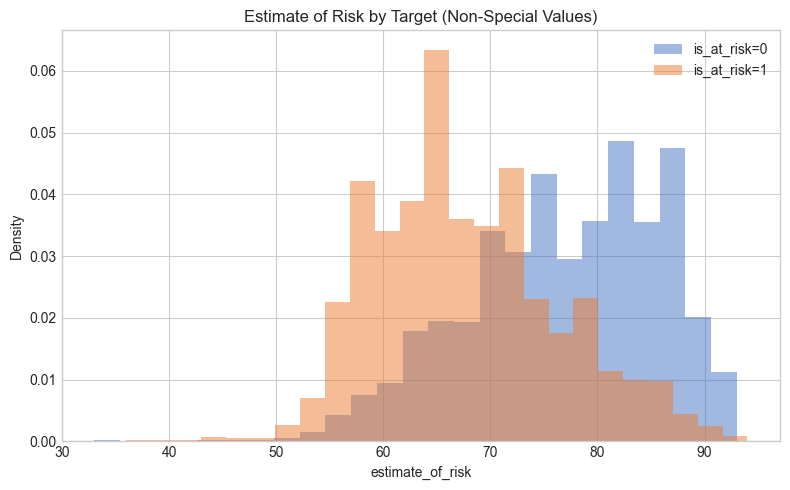

In [5]:
risk_estimate = raw_df["estimate_of_risk"]
valid_risk = risk_estimate.ge(0)
pb_raw = pointbiserialr(y, risk_estimate)
pb_valid = pointbiserialr(y.loc[valid_risk], risk_estimate.loc[valid_risk])

estimate_rows = [
    {"metric": "unique_values", "value": risk_estimate.nunique(), "scope": "all rows"},
    {"metric": "minimum", "value": risk_estimate.min(), "scope": "all rows"},
    {"metric": "maximum", "value": risk_estimate.max(), "scope": "all rows"},
    {"metric": "special_coded_rows", "value": risk_estimate.isin(SPECIAL_CODES).sum(), "scope": "all rows"},
    {"metric": "point_biserial_correlation", "value": pb_raw.statistic, "scope": "raw including special codes"},
    {"metric": "point_biserial_pvalue", "value": pb_raw.pvalue, "scope": "raw including special codes"},
    {"metric": "point_biserial_correlation", "value": pb_valid.statistic, "scope": "valid values >= 0"},
    {"metric": "point_biserial_pvalue", "value": pb_valid.pvalue, "scope": "valid values >= 0"},
]
for target_value, values in raw_df.groupby(TARGET)["estimate_of_risk"]:
    estimate_rows.extend([
        {"metric": "mean", "value": values.mean(), "scope": f"target={target_value}, raw"},
        {"metric": "median", "value": values.median(), "scope": f"target={target_value}, raw"},
        {"metric": "mean", "value": values.loc[values.ge(0)].mean(), "scope": f"target={target_value}, valid >= 0"},
        {"metric": "median", "value": values.loc[values.ge(0)].median(), "scope": f"target={target_value}, valid >= 0"},
    ])
estimate_of_risk_audit = pd.DataFrame(estimate_rows)
estimate_of_risk_audit["provenance_status"] = "Construction and timing unresolved"
estimate_of_risk_audit["primary_model_decision"] = "EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED TARGET/SCORE-LEAKAGE RISK"
estimate_of_risk_audit.to_csv(ARTIFACT_DIR / "estimate_of_risk_audit.csv", index=False)
display(estimate_of_risk_audit)

fig, ax = plt.subplots(figsize=(8, 5))
for target_value, color in [(0, "#4472C4"), (1, "#ED7D31")]:
    values = raw_df.loc[y.eq(target_value) & valid_risk, "estimate_of_risk"]
    ax.hist(values, bins=25, density=True, alpha=0.5, label=f"is_at_risk={target_value}", color=color)
ax.set(title="Estimate of Risk by Target (Non-Special Values)", xlabel="estimate_of_risk", ylabel="Density")
ax.legend(); plt.tight_layout(); plt.savefig(PLOT_DIR / "heloc_estimate_of_risk_by_target.png", dpi=300); plt.show()

## 6. Feature associations

Spearman relationships are calculated both on raw codes and pairwise after excluding `-7`, `-8`, and `-9`. Large differences indicate that special codes affect the raw relationship.

,feature_a,feature_b,raw_spearman,valid_only_spearman,absolute_raw_spearman,absolute_valid_only_spearman,valid_pair_count,absolute_difference
225,nr_inquiries_in_last_6_months,nr_inquiries_in_last_6_months_not_recent,0.985389,0.982358,0.985389,0.982358,9871,0.003031
135,percentage_of_legal_trades,maximum_illegal_trades,0.919387,0.902201,0.919387,0.902201,9871,0.017187
88,number_of_satisfactory_trades,nr_total_trades,0.881711,0.859296,0.881711,0.859296,9871,0.022415
100,nr_trades_insolvent_for_over_60_days,nr_trades_insolvent_for_over_90_days,0.871227,0.831627,0.871227,0.831627,9871,0.039600
134,percentage_of_legal_trades,maximum_illegal_trades_over_last_year,0.860073,0.830364,0.860073,0.830364,9871,0.029709
162,maximum_illegal_trades_over_last_year,maximum_illegal_trades,0.853808,0.822402,0.853808,0.822402,9871,0.031406
148,months_since_last_illegal_trade,maximum_illegal_trades_over_last_year,-0.339785,0.782688,0.339785,0.782688,5031,1.122472
52,months_since_last_trade,nr_trades_initiated_in_last_year,-0.469817,-0.755190,0.469817,0.755190,9871,0.285373
23,months_since_first_trade,average_duration_of_resolution,0.740027,0.723615,0.740027,0.723615,9632,0.016413
241,net_fraction_of_revolving_burden,nr_banks_with_high_ratio,0.730090,0.699812,0.730090,0.699812,9282,0.030278


,feature,unique_count,dominant_value,dominant_value_percentage,special_value_percentage,skew_valid_values
6,nr_trades_insolvent_for_over_90_days,17,0,73.037575,5.621952,5.454785
5,nr_trades_insolvent_for_over_60_days,19,0,65.034898,5.621952,4.169829
8,months_since_last_illegal_trade,87,-7,44.593173,51.897887,1.066216
7,percentage_of_legal_trades,72,100,44.048188,5.621952,-2.430945
14,months_since_last_inquiry_not_recent,28,0,43.809160,27.908978,2.401897
10,maximum_illegal_trades,8,8,43.331102,5.621952,-0.982103
21,nr_banks_with_high_ratio,19,0,41.189406,11.196099,2.563575
9,maximum_illegal_trades_over_last_year,10,7,40.376709,5.621952,-1.777080
16,nr_inquiries_in_last_6_months_not_recent,27,0,38.990343,5.621952,6.416264
15,nr_inquiries_in_last_6_months,27,0,37.517927,5.621952,6.155849


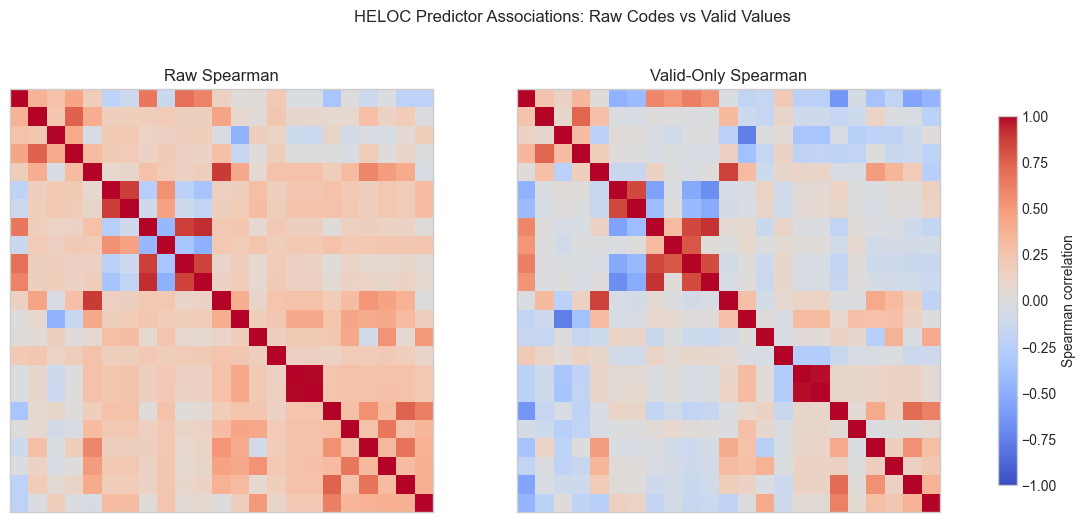

In [6]:
raw_spearman = X.corr(method="spearman")
valid_X = X.mask(X.isin(SPECIAL_CODES))
valid_spearman = valid_X.corr(method="spearman", min_periods=100)

association_rows = []
for i, feature_a in enumerate(predictors):
    for feature_b in predictors[i + 1:]:
        raw_rho = raw_spearman.loc[feature_a, feature_b]
        valid_rho = valid_spearman.loc[feature_a, feature_b]
        valid_pairs = int(valid_X[[feature_a, feature_b]].notna().all(axis=1).sum())
        association_rows.append({"feature_a": feature_a, "feature_b": feature_b,
            "raw_spearman": raw_rho, "valid_only_spearman": valid_rho,
            "absolute_raw_spearman": abs(raw_rho), "absolute_valid_only_spearman": abs(valid_rho),
            "valid_pair_count": valid_pairs,
            "absolute_difference": abs(raw_rho - valid_rho) if pd.notna(valid_rho) else np.nan})
feature_association_summary = pd.DataFrame(association_rows).sort_values("absolute_valid_only_spearman", ascending=False)
feature_association_summary.to_csv(ARTIFACT_DIR / "feature_association_summary.csv", index=False)
display(feature_association_summary.head(20))

distribution_audit = pd.DataFrame({
    "feature": predictors,
    "unique_count": X.nunique().values,
    "dominant_value": [X[c].value_counts().index[0] for c in predictors],
    "dominant_value_percentage": [100 * X[c].value_counts(normalize=True).iloc[0] for c in predictors],
    "special_value_percentage": [100 * X[c].isin(SPECIAL_CODES).mean() for c in predictors],
    "skew_valid_values": [X.loc[X[c].ge(0), c].skew() for c in predictors],
})
display(distribution_audit.sort_values("dominant_value_percentage", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for matrix, title, ax in [(raw_spearman, "Raw Spearman", axes[0]), (valid_spearman, "Valid-Only Spearman", axes[1])]:
    image = ax.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(image, ax=axes, shrink=0.8, label="Spearman correlation")
fig.suptitle("HELOC Predictor Associations: Raw Codes vs Valid Values")
plt.savefig(PLOT_DIR / "heloc_feature_association_comparison.png", dpi=300, bbox_inches="tight"); plt.show()

## 7. Descriptive target association

Point-biserial correlations summarize univariate association only. They are not used for automated feature selection or model optimization.

In [7]:
target_rows = []
for feature in predictors:
    raw_result = pointbiserialr(y, X[feature])
    valid = X[feature].ge(0)
    valid_result = pointbiserialr(y.loc[valid], X.loc[valid, feature]) if valid.sum() > 2 else (np.nan, np.nan)
    target_rows.append({"feature": feature, "raw_point_biserial": raw_result.statistic,
        "valid_only_point_biserial": valid_result.statistic, "valid_row_count": int(valid.sum()),
        "target_0_valid_mean": X.loc[valid & y.eq(0), feature].mean(),
        "target_1_valid_mean": X.loc[valid & y.eq(1), feature].mean()})
feature_target_association = pd.DataFrame(target_rows)
feature_target_association["absolute_valid_only_association"] = feature_target_association.valid_only_point_biserial.abs()
feature_target_association = feature_target_association.sort_values("absolute_valid_only_association", ascending=False)
feature_target_association.to_csv(ARTIFACT_DIR / "feature_target_association.csv", index=False)
display(feature_target_association)

,feature,raw_point_biserial,valid_only_point_biserial,valid_row_count,target_0_valid_mean,target_1_valid_mean,absolute_valid_only_association
0,estimate_of_risk,-0.216770,-0.460381,9861,76.790830,67.694423,0.460381
17,net_fraction_of_revolving_burden,0.298174,0.355754,9685,24.266709,44.834971,0.355754
22,percentage_trades_with_balance,0.198554,0.279369,9853,60.043965,72.365092,0.279369
7,percentage_of_legal_trades,-0.122010,-0.257358,9871,95.515312,89.450935,0.257358
21,nr_banks_with_high_ratio,0.029091,0.245632,9288,0.709290,1.464036,0.245632
3,average_duration_of_resolution,-0.209168,-0.243869,9871,87.429989,70.801791,0.243869
9,maximum_illegal_trades_over_last_year,-0.109946,-0.236759,9871,6.163464,5.384151,0.236759
10,maximum_illegal_trades,-0.107204,-0.216764,9871,6.791975,5.989681,0.216764
1,months_since_first_trade,-0.185155,-0.216058,9632,222.786595,180.431396,0.216058
14,months_since_last_inquiry_not_recent,-0.110253,-0.192686,7540,3.431410,1.595609,0.192686


## 8. Feature semantics, proxy and eligibility audit

Human-readable labels are mechanical expansions of source names, not new definitions. No direct protected attribute is identified; credit-history variables are assessed as possible socioeconomic proxies rather than protected attributes.

In [8]:
def display_name(feature): return feature.replace("nr_", "number_of_").replace("_", " ").title()

def proxy_class(feature):
    if any(term in feature for term in ["trade", "burden", "balance", "inquir", "bank"]):
        return "potential socioeconomic proxy / ordinary credit-behaviour variable"
    return "uncertain; no direct protected attribute identified"

def actionability(feature):
    if feature == "estimate_of_risk": return "unsuitable / unresolved"
    if any(term in feature for term in ["burden", "balance", "percentage_trades_with_balance"]): return "partially actionable"
    return "non-actionable"

semantics_rows = []
for feature in predictors:
    special_values = sorted(X.loc[X[feature].isin(SPECIAL_CODES), feature].unique().astype(int).tolist())
    excluded = feature == "estimate_of_risk"
    semantics_rows.append({
        "raw_feature_name": feature, "display_name": display_name(feature),
        "verified_description": "Detailed definition not provided by frozen source metadata; source feature name retained",
        "description_status": "UNCONFIRMED beyond source name", "dtype": str(X[feature].dtype),
        "observed_minimum": X[feature].min(), "observed_maximum": X[feature].max(),
        "special_value_codes": ", ".join(map(str, special_values)) if special_values else "none observed",
        "special_value_prevalence_percent": 100 * X[feature].isin(SPECIAL_CODES).mean(),
        "likely_availability_at_credit_decision_time": "Likely credit-report information, but exact timing requires confirmation",
        "leakage_concern": "High: unresolved existing score / target proxy" if excluded else "No obvious leakage verified; definition and timing still require review",
        "sensitive_proxy_concern": proxy_class(feature),
        "preliminary_modelling_eligibility": "exclude from primary model" if excluded else "provisionally eligible",
        "preliminary_dice_actionability": actionability(feature),
        "notes": "Do not interpret special codes as ordered numeric measurements",
    })
feature_semantics_audit = pd.DataFrame(semantics_rows)
feature_semantics_audit.to_csv(ARTIFACT_DIR / "feature_semantics_audit.csv", index=False)
xai_actionability_audit = feature_semantics_audit[["raw_feature_name", "display_name", "preliminary_dice_actionability", "notes"]].copy()
xai_actionability_audit.to_csv(ARTIFACT_DIR / "xai_actionability_audit.csv", index=False)
display(feature_semantics_audit)

,raw_feature_name,display_name,verified_description,description_status,dtype,observed_minimum,observed_maximum,special_value_codes,special_value_prevalence_percent,likely_availability_at_credit_decision_time,leakage_concern,sensitive_proxy_concern,preliminary_modelling_eligibility,preliminary_dice_actionability,notes
0,estimate_of_risk,Estimate Of Risk,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,94,-9,5.717564,"Likely credit-report information, but exact ti...",High: unresolved existing score / target proxy,uncertain; no direct protected attribute ident...,exclude from primary model,unsuitable / unresolved,Do not interpret special codes as ordered nume...
1,months_since_first_trade,Months Since First Trade,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,803,"-9, -8",7.907066,"Likely credit-report information, but exact ti...",No obvious leakage verified; definition and ti...,potential socioeconomic proxy / ordinary credi...,provisionally eligible,non-actionable,Do not interpret special codes as ordered nume...
2,months_since_last_trade,Months Since Last Trade,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,383,-9,5.621952,"Likely credit-report information, but exact ti...",No obvious leakage verified; definition and ti...,potential socioeconomic proxy / ordinary credi...,provisionally eligible,non-actionable,Do not interpret special codes as ordered nume...
3,average_duration_of_resolution,Average Duration Of Resolution,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,383,-9,5.621952,"Likely credit-report information, but exact ti...",No obvious leakage verified; definition and ti...,uncertain; no direct protected attribute ident...,provisionally eligible,non-actionable,Do not interpret special codes as ordered nume...
4,number_of_satisfactory_trades,Number Of Satisfactory Trades,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,79,-9,5.621952,"Likely credit-report information, but exact ti...",No obvious leakage verified; definition and ti...,potential socioeconomic proxy / ordinary credi...,provisionally eligible,non-actionable,Do not interpret special codes as ordered nume...
5,nr_trades_insolvent_for_over_60_days,Number Of Trades Insolvent For Over 60 Days,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,19,-9,5.621952,"Likely credit-report information, but exact ti...",No obvious leakage verified; definition and ti...,potential socioeconomic proxy / ordinary credi...,provisionally eligible,non-actionable,Do not interpret special codes as ordered nume...
6,nr_trades_insolvent_for_over_90_days,Number Of Trades Insolvent For Over 90 Days,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,19,-9,5.621952,"Likely credit-report information, but exact ti...",No obvious leakage verified; definition and ti...,potential socioeconomic proxy / ordinary credi...,provisionally eligible,non-actionable,Do not interpret special codes as ordered nume...
7,percentage_of_legal_trades,Percentage Of Legal Trades,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,100,-9,5.621952,"Likely credit-report information, but exact ti...",No obvious leakage verified; definition and ti...,potential socioeconomic proxy / ordinary credi...,provisionally eligible,non-actionable,Do not interpret special codes as ordered nume...
8,months_since_last_illegal_trade,Months Since Last Illegal Trade,Detailed definition not provided by frozen sou...,UNCONFIRMED beyond source name,int64,-9,83,"-9, -8, -7",51.897887,"Likely credit-report information, but exact ti...",No obvious leakage verified; definition and ti...,potential socioeconomic proxy / ordinary credi...,provisionally eligible,non-actionable,Do not interpret special codes as ordered n

## 9. Preliminary feature set and Stage 03 recommendation

Correlation, skew and special-value prevalence do not cause exclusion by themselves. Only `estimate_of_risk` is excluded from the proposed primary feature set because score or target leakage cannot be ruled out.

In [9]:
excluded_features = [{
    "feature": "estimate_of_risk",
    "reason": "EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED TARGET/SCORE-LEAKAGE RISK",
}]
selected_features = [feature for feature in predictors if feature != "estimate_of_risk"]
selected_feature_payload = {
    "target": TARGET,
    "selected_feature_count": len(selected_features),
    "selected_features": selected_features,
    "excluded_features": excluded_features,
    "decision_scope": "preliminary Stage 02 recommendation for Stage 03",
    "raw_data_modified": False,
}
with open(ARTIFACT_DIR / "selected_features.json", "w", encoding="utf-8") as handle:
    json.dump(selected_feature_payload, handle, indent=2)

stage03_recommendation = {
    "special_values": "For non-all--9 rows, preserve distinct -7/-8/-9 indicators and treat the underlying measurements as missing inside a training-fitted pipeline; use training-only robust/median imputation. Final treatment requires semantic approval.",
    "all_minus_9_rows": "Remove all 588 before splitting because predictors contain no measured information, labels conflict, and repeated profiles risk partition leakage.",
    "exact_duplicates": "After the all--9 exclusion, remove the one remaining exact duplicate excess row before splitting.",
    "conflicting_target_profiles": "The only observed conflicting profile is the all--9 profile; exclude the entire profile rather than selecting a label.",
    "estimate_of_risk": excluded_features[0]["reason"],
    "selected_feature_count": len(selected_features),
    "selected_features": selected_features,
    "preprocessing": "Fit all missing indicators, imputation and any scaling on training data only. Do not use negative codes as ordered numeric magnitudes.",
    "split_strategy": "Use a reproducible stratified split after approved pre-split row policy; group by complete predictor profile to prevent identical-profile leakage.",
    "class_balance": "Reassess target counts after approved row policy; use stratification and training-only weighting if later justified.",
    "validation": "Reserve the untouched test partition for final evaluation; perform model comparison and tuning only within training data using grouped stratified validation where feasible.",
    "implemented_in_stage_02": False,
}
with open(ARTIFACT_DIR / "stage03_recommendation.json", "w", encoding="utf-8") as handle:
    json.dump(stage03_recommendation, handle, indent=2)

print("Proposed selected features:", len(selected_features))
print(selected_features)
print("Proposed exclusion:", excluded_features)

Proposed selected features: 22
['months_since_first_trade', 'months_since_last_trade', 'average_duration_of_resolution', 'number_of_satisfactory_trades', 'nr_trades_insolvent_for_over_60_days', 'nr_trades_insolvent_for_over_90_days', 'percentage_of_legal_trades', 'months_since_last_illegal_trade', 'maximum_illegal_trades_over_last_year', 'maximum_illegal_trades', 'nr_total_trades', 'nr_trades_initiated_in_last_year', 'percentage_of_installment_trades', 'months_since_last_inquiry_not_recent', 'nr_inquiries_in_last_6_months', 'nr_inquiries_in_last_6_months_not_recent', 'net_fraction_of_revolving_burden', 'net_fraction_of_installment_burden', 'nr_revolving_trades_with_balance', 'nr_installment_trades_with_balance', 'nr_banks_with_high_ratio', 'percentage_trades_with_balance']
Proposed exclusion: [{'feature': 'estimate_of_risk', 'reason': 'EXCLUDE FROM PRIMARY MODEL DUE TO UNRESOLVED TARGET/SCORE-LEAKAGE RISK'}]


## 10. Quality checks

The raw snapshot remains unchanged and all Stage 02 results are descriptive or recommendations.

In [10]:
assert raw_df.shape == (10_459, 24)
assert len(predictors) == 23 and TARGET == "is_at_risk"
assert set(y.unique()) == {0, 1}
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_HASH
assert len(all_minus9) == 588
assert all_minus9[predictors].drop_duplicates().shape[0] == 1
assert all_minus9.drop_duplicates().shape[0] == 2
assert int(raw_df.duplicated().sum()) == 587
assert int(X.duplicated().sum()) == 588
assert int(duplicate_profiles.target_classes.gt(1).sum()) == 1
assert len(selected_features) == 22 and excluded_features[0]["feature"] == "estimate_of_risk"
assert len(feature_semantics_audit) == 23

print("Raw rows: 10,459")
print("Raw columns: 24")
print("Target unchanged: True")
print("Raw SHA-256 unchanged: True")
print("Rows removed: 0")
print("Preprocessing fitted: False")
print("Model trained: False")
print("Split created: False")
print("XAI executed: False")

Raw rows: 10,459
Raw columns: 24
Target unchanged: True
Raw SHA-256 unchanged: True
Rows removed: 0
Preprocessing fitted: False
Model trained: False
Split created: False
XAI executed: False


## 11. Decisions required before Stage 03

Approval is needed for the proposed all-`-9` exclusion, remaining exact-duplicate removal, grouped stratified splitting, and special-code indicator/imputation strategy. The conservative exclusion of `estimate_of_risk` should remain unless authoritative provenance establishes that it is an ordinary decision-time predictor without score or target leakage.